# Estudio capa fina

## Sodio $Na$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib widget

In [2]:
with open('/home/edgar/GitHub/Proyectos/Proyectos_python/FISICA/TEIII/archivos_py/segundo_cuatri/archive/NA I ahora si.txt', 'r') as file:
    Datos = file.read()

Datos = Datos.split('\n')

for fila in Datos:
    Datos[Datos.index(fila)] = fila.split(';')

for i in range(len(Datos)):
    for j in range(len(Datos[i])):
        Datos[i][j] = Datos[i][j].replace(',', '.')
        Datos[i][j] = float(Datos[i][j])

Datos = np.array(Datos)

numero_picos = 0
dentro_pico = False
ubicacion_picos = []
máximo_pico = 0

for fila in Datos:
    if fila[4] > máximo_pico:
        máximo_pico = fila[4]
        index = fila[0]
    if fila[4] > 9 and not dentro_pico:
        numero_picos += 1
        dentro_pico = True
        
    elif fila[4] <= 9 and dentro_pico:
        dentro_pico = False
        ubicacion_picos.append(index)
        máximo_pico = 0



print("Número de picos:", numero_picos)
print("Ubicación de los picos:")
for ubicacion in ubicacion_picos:
    print(f"pico {ubicacion_picos.index(ubicacion) + 1}: {ubicacion:.2f} nm")


Número de picos: 30
Ubicación de los picos:
pico 1: 415.88 nm
pico 2: 419.91 nm
pico 3: 455.31 nm
pico 4: 493.36 nm
pico 5: 498.16 nm
pico 6: 568.82 nm
pico 7: 588.93 nm
pico 8: 605.09 nm
pico 9: 606.59 nm
pico 10: 616.00 nm
pico 11: 696.49 nm
pico 12: 706.64 nm
pico 13: 714.66 nm
pico 14: 727.22 nm
pico 15: 737.12 nm
pico 16: 738.29 nm
pico 17: 751.38 nm
pico 18: 763.36 nm
pico 19: 766.44 nm
pico 20: 769.78 nm
pico 21: 772.34 nm
pico 22: 794.75 nm
pico 23: 801.33 nm
pico 24: 811.41 nm
pico 25: 813.30 nm
pico 26: 819.44 nm
pico 27: 826.31 nm
pico 28: 842.34 nm
pico 29: 852.10 nm
pico 30: 866.69 nm


### Gráfica

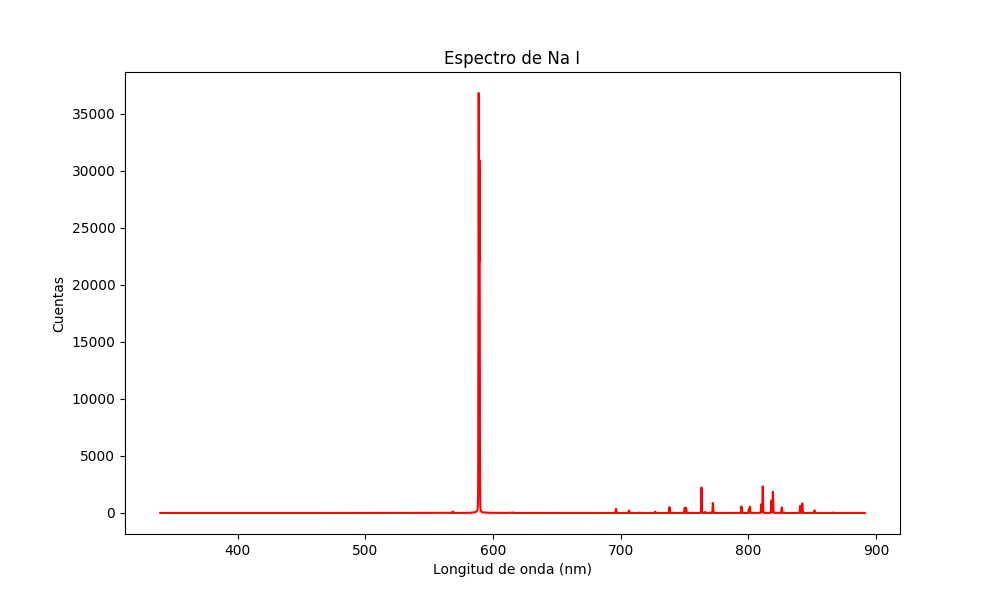

In [3]:
plt.figure(figsize=(10, 6))
plt.plot(Datos[:, 0], Datos[:, 4], label='Na I', color='red')
plt.xlabel('Longitud de onda (nm)')
plt.ylabel('Cuentas')
plt.title('Espectro de Na I')
plt.show()

### Diagrama

Energías de los estados s de Na: [    0.    25739.999 33200.673 36372.618 38012.042 38968.51  39574.85 ]
Energías de los estados p de Na: [16956.17025 16973.36619 30266.99    30272.58    35040.38    35042.85
 37296.32    37297.61    38540.18    38540.93    39298.35    39298.84   ]
Energías de los estados d de Na: [29172.837 29172.887 34548.729 34548.764 37036.752 37036.772 38387.255
 38387.268 39200.93  39200.93  39728.7   39728.7  ]


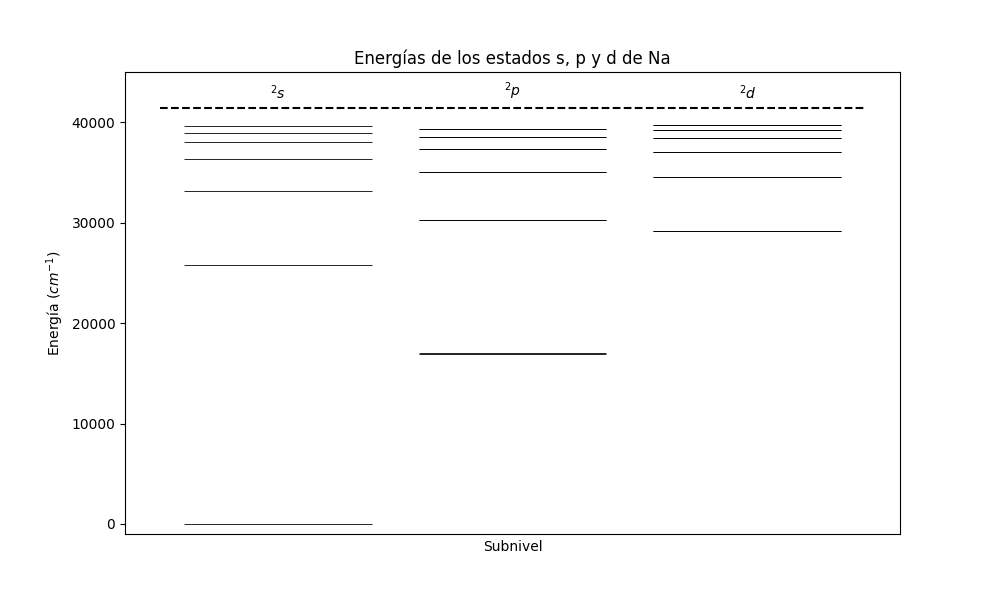

In [4]:
import pandas as pd
Data =pd.read_excel('/home/edgar/Descargas/PL2_Practica4B_Grupo6.xlsx')

Bins = [r"$^2s$",r"$^2p$",r"$^2d$"]

Datos_Energia_s_Na =[]
Datos_Energia_p_Na =[]
Datos_Energia_d_Na =[]


for i in range(len(Data)):
    if Data.iloc[i, 2] == ' 2S ':
            Datos_Energia_s_Na.append(Data.iloc[i, 3])
    elif Data.iloc[i, 2] == ' 2P° ':
            Datos_Energia_p_Na.append(Data.iloc[i, 3])
            Datos_Energia_p_Na.append(Data.iloc[i+1, 3])
    elif Data.iloc[i, 2] == ' 2D ':
            Datos_Energia_d_Na.append(Data.iloc[i, 3])
            Datos_Energia_d_Na.append(Data.iloc[i+1, 3])


for i in range(len(Datos_Energia_s_Na)-1):
    Datos_Energia_s_Na[i+1] = Datos_Energia_s_Na[i+1].replace(' ', '')
    Datos_Energia_s_Na[i+1] = float(Datos_Energia_s_Na[i+1])

for i in range(len(Datos_Energia_p_Na)):
    Datos_Energia_p_Na[i] = Datos_Energia_p_Na[i].replace(' ', '')
    Datos_Energia_p_Na[i] = float(Datos_Energia_p_Na[i])

for i in range(len(Datos_Energia_d_Na)):
    Datos_Energia_d_Na[i] = Datos_Energia_d_Na[i].replace(' ', '')
    Datos_Energia_d_Na[i] = float(Datos_Energia_d_Na[i])

Energia_s = np.array(Datos_Energia_s_Na)
Energia_p = np.array(Datos_Energia_p_Na)
Energia_d = np.array(Datos_Energia_d_Na)

print("Energías de los estados s de Na:", Energia_s)
print("Energías de los estados p de Na:", Energia_p)
print("Energías de los estados d de Na:", Energia_d)



plt.figure(figsize=(10, 6))
plt.hlines(Energia_s, 0.1, 0.9, label='s', color='black',linewidth=0.6)
plt.hlines(Energia_p, 1.1, 1.9, label='p', color='black',linewidth=0.6)
plt.hlines(Energia_d, 2.1, 2.9, label='d', color='black',linewidth=0.6)
plt.hlines(41455,0,3, label='Ionización', color='black', linestyle='dashed')
plt.xlabel('Subnivel')
plt.xticks([])
plt.ylabel(r'Energía $(cm^{-1})$')
plt.title('Energías de los estados s, p y d de Na')
plt.ylim(-1000, 45000)
plt.text(0.5, 42000, r'$^2s$', ha='center', va='bottom')
plt.text(1.5, 42000, r'$^2p$', ha='center', va='bottom')
plt.text(2.5, 42000, r'$^2d$', ha='center', va='bottom')
plt.show()



## Zinc $Zn$

In [5]:
with open('/home/edgar/GitHub/Proyectos/Proyectos_python/FISICA/TEIII/archivos_py/segundo_cuatri/archive/ZN I.txt', 'r') as file:
    Datos = file.read()

Datos = Datos.split('\n')

for fila in Datos:
    Datos[Datos.index(fila)] = fila.split(';')

for i in range(len(Datos)):
    for j in range(len(Datos[i])):
        Datos[i][j] = Datos[i][j].replace(',', '.')
        Datos[i][j] = float(Datos[i][j])

Datos = np.array(Datos)

numero_picos = 0
dentro_pico = False
ubicacion_picos = []
máximo_pico = 0

for fila in Datos:
    if fila[4] > máximo_pico:
        máximo_pico = fila[4]
        index = fila[0]
    if fila[4] > 9 and not dentro_pico:
        numero_picos += 1
        dentro_pico = True
        
    elif fila[4] <= 9 and dentro_pico:
        dentro_pico = False
        ubicacion_picos.append(index)
        máximo_pico = 0



print("Número de picos:", numero_picos)
print("Ubicación de los picos:")
for ubicacion in ubicacion_picos:
    print(f"pico {ubicacion_picos.index(ubicacion) + 1}: {ubicacion:.2f} nm")

Número de picos: 31
Ubicación de los picos:
pico 1: 346.61 nm
pico 2: 361.07 nm
pico 3: 481.05 nm
pico 4: 508.58 nm
pico 5: 518.13 nm
pico 6: 615.04 nm
pico 7: 636.20 nm
pico 8: 641.33 nm
pico 9: 643.76 nm
pico 10: 692.78 nm
pico 11: 693.71 nm
pico 12: 696.49 nm
pico 13: 706.64 nm
pico 14: 727.22 nm
pico 15: 738.29 nm
pico 16: 747.76 nm
pico 17: 750.34 nm
pico 18: 751.38 nm
pico 19: 763.36 nm
pico 20: 772.34 nm
pico 21: 779.88 nm
pico 22: 794.75 nm
pico 23: 801.33 nm
pico 24: 811.41 nm
pico 25: 826.31 nm
pico 26: 840.74 nm
pico 27: 842.34 nm
pico 28: 852.10 nm
pico 29: 866.69 nm
pico 30: 877.90 nm
pico 31: 879.36 nm


### Diagrama

Energías de los estados s de Zn: []
Energías de los estados s de Zn: [    0.     55789.216  66037.6663 70003.737 ]
Energías de los estados p de Zn: [46745.4032 62910.436  68607.231  71218.994 ]
Energías de los estados d de Zn: [62458.5323 68338.5233 71051.04  ]
Energías de los estados s de Zn: []
Energías de los estados p de Zn: [32311.3176 32501.399  32890.3267 61247.866  61274.419  61330.845
 68070.882  68080.708  68101.825  70977.365  70982.101  70992.304 ]
Energías de los estados d de Zn: [62768.7462 62772.0144 62776.9809 68579.1399 68580.7053 68583.0827
 71212.138  71212.9743 71214.243 ]


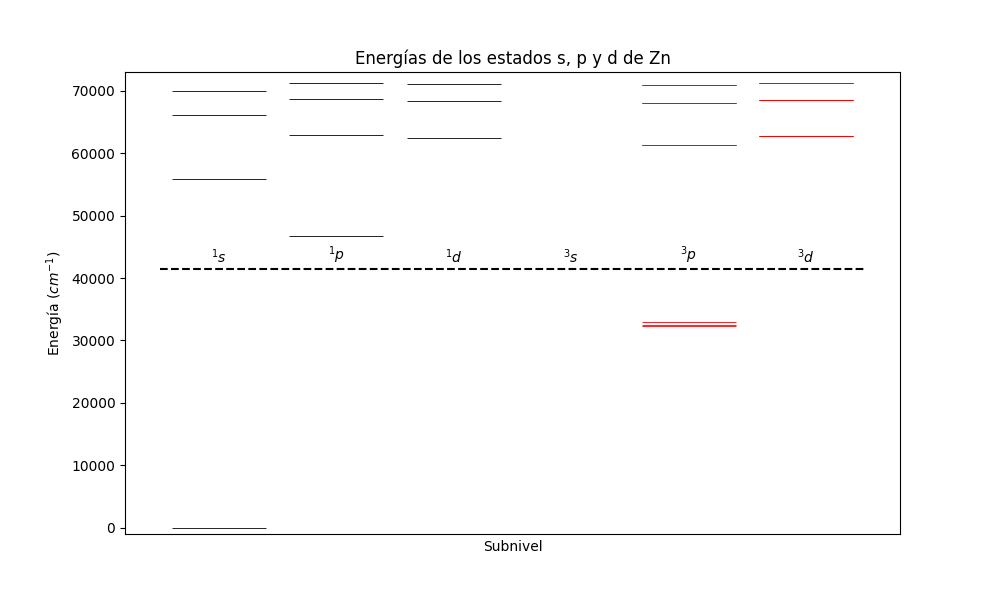

In [ ]:
Datos_Energia_s_Zn_1 =[]
Datos_Energia_p_Zn_1 =[]
Datos_Energia_d_Zn_1 =[]
Datos_Energia_s_Zn_3 =[]
Datos_Energia_p_Zn_3 =[]
Datos_Energia_d_Zn_3 =[]


for i in range(len(Data)):
    if Data.iloc[i, 7] == '3S':
            Datos_Energia_s_Zn_3.append(Data.iloc[i, 8])
    elif Data.iloc[i, 7] == '3P0':
            Datos_Energia_p_Zn_3.append(Data.iloc[i, 8])
            Datos_Energia_p_Zn_3.append(Data.iloc[i+1, 8])
            Datos_Energia_p_Zn_3.append(Data.iloc[i+2, 8])
    elif Data.iloc[i, 7] == '3D':
            Datos_Energia_d_Zn_3.append(Data.iloc[i, 8])
            Datos_Energia_d_Zn_3.append(Data.iloc[i+1, 8])
            Datos_Energia_d_Zn_3.append(Data.iloc[i+2, 8])
    elif Data.iloc[i, 7] == '1S':
            Datos_Energia_s_Zn_1.append(Data.iloc[i, 8])
    elif Data.iloc[i, 7] == '1P0':
            Datos_Energia_p_Zn_1.append(Data.iloc[i, 8])
    elif Data.iloc[i, 7] == '1D':
            Datos_Energia_d_Zn_1.append(Data.iloc[i, 8])

print ("Energías de los estados s de Zn:", Datos_Energia_s_Zn_3)

for i in range(len(Datos_Energia_s_Zn_1)-1):
    Datos_Energia_s_Zn_1[i+1] = Datos_Energia_s_Zn_1[i+1].replace(' ', '')
    Datos_Energia_s_Zn_1[i+1] = float(Datos_Energia_s_Zn_1[i+1])

for i in range(len(Datos_Energia_p_Zn_1)):
    Datos_Energia_p_Zn_1[i] = Datos_Energia_p_Zn_1[i].replace(' ', '')
    Datos_Energia_p_Zn_1[i] = float(Datos_Energia_p_Zn_1[i])

for i in range(len(Datos_Energia_d_Zn_1)):
    Datos_Energia_d_Zn_1[i] = Datos_Energia_d_Zn_1[i].replace(' ', '')
    Datos_Energia_d_Zn_1[i] = float(Datos_Energia_d_Zn_1[i])

for i in range(len(Datos_Energia_s_Zn_3)):
    Datos_Energia_s_Zn_3[i] = Datos_Energia_s_Zn_3[i].replace(' ', '')
    Datos_Energia_s_Zn_3[i] = float(Datos_Energia_s_Zn_3[i])

for i in range(len(Datos_Energia_p_Zn_3)):
    Datos_Energia_p_Zn_3[i] = Datos_Energia_p_Zn_3[i].replace(' ', '')
    Datos_Energia_p_Zn_3[i] = float(Datos_Energia_p_Zn_3[i])

for i in range(len(Datos_Energia_d_Zn_3)):
    Datos_Energia_d_Zn_3[i] = Datos_Energia_d_Zn_3[i].replace(' ', '')
    Datos_Energia_d_Zn_3[i] = float(Datos_Energia_d_Zn_3[i])


Energia_s_1 = np.array(Datos_Energia_s_Zn_1)
Energia_p_1 = np.array(Datos_Energia_p_Zn_1)
Energia_d_1 = np.array(Datos_Energia_d_Zn_1)
Energia_s_3 = np.array(Datos_Energia_s_Zn_3)
Energia_p_3 = np.array(Datos_Energia_p_Zn_3)
Energia_d_3 = np.array(Datos_Energia_d_Zn_3)

print("Energías de los estados s de Zn:", Energia_s_1)
print("Energías de los estados p de Zn:", Energia_p_1)
print("Energías de los estados d de Zn:", Energia_d_1)
print("Energías de los estados s de Zn:", Energia_s_3)
print("Energías de los estados p de Zn:", Energia_p_3)
print("Energías de los estados d de Zn:", Energia_d_3)



plt.figure(figsize=(10, 6))
plt.hlines(Energia_s_1, 0.1, 0.9, label='s', color='black',linewidth=0.6)
plt.hlines(Energia_p_1, 1.1, 1.9, label='p', color='black',linewidth=0.6)
plt.hlines(Energia_d_1, 2.1, 2.9, label='d', color='black',linewidth=0.6)
plt.hlines(Energia_s_3, 3.1, 3.9, label='s', color='red',linewidth=0.6)
plt.hlines(Energia_p_3, 4.1, 4.9, label='p', color='red',linewidth=0.6)
plt.hlines(Energia_d_3, 5.1, 5.9, label='d', color='red',linewidth=0.6)
plt.hlines(41455,0,6, label='Ionización', color='black', linestyle='dashed')
plt.xlabel('Subnivel')
plt.xticks([])
plt.ylabel(r'Energía $(cm^{-1})$')
plt.title('Energías de los estados s, p y d de Zn')
plt.ylim(-1000, 73000)
plt.text(0.5, 42000, r'$^1s$', ha='center', va='bottom')
plt.text(1.5, 42000, r'$^1p$', ha='center', va='bottom')
plt.text(2.5, 42000, r'$^1d$', ha='center', va='bottom')
plt.text(3.5, 42000, r'$^3s$', ha='center', va='bottom')
plt.text(4.5, 42000, r'$^3p$', ha='center', va='bottom')
plt.text(5.5, 42000, r'$^3d$', ha='center', va='bottom')
plt.show()


### Gráfica

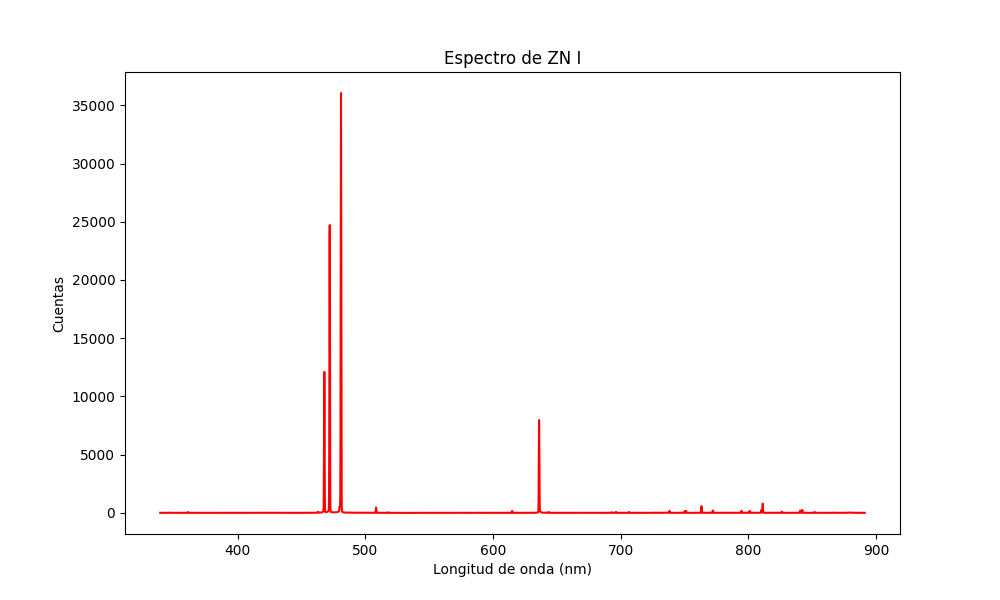

In [7]:
plt.figure(figsize=(10, 6))
plt.plot(Datos[:, 0], Datos[:, 4], label='ZN I', color='red')
plt.xlabel('Longitud de onda (nm)')
plt.ylabel('Cuentas')
plt.title('Espectro de ZN I')
plt.show()

### Diagrama

In [8]:
Bins = [r"$^2s$",r"$^2p$",r"$^2d$"]

Datos_Energia_1 =[0,0,0]
Datos_Energia_2 =[]



## Mercurio $Hg$

In [9]:
with open('/home/edgar/GitHub/Proyectos/Proyectos_python/FISICA/TEIII/archivos_py/segundo_cuatri/archive/Hg I 2.txt', 'r') as file:
    Datos = file.read()

Datos = Datos.split('\n')

for fila in Datos:
    Datos[Datos.index(fila)] = fila.split(';')

for i in range(len(Datos)):
    for j in range(len(Datos[i])):
        Datos[i][j] = Datos[i][j].replace(',', '.')
        Datos[i][j] = float(Datos[i][j])

Datos = np.array(Datos)

numero_picos = 0
dentro_pico = False
ubicacion_picos = []
máximo_pico = 0

for fila in Datos:
    if fila[4] > máximo_pico:
        máximo_pico = fila[4]
        index = fila[0]
    if fila[4] > 100 and not dentro_pico:
        numero_picos += 1
        dentro_pico = True
        
    elif fila[4] <= 100 and dentro_pico:
        dentro_pico = False
        ubicacion_picos.append(index)
        máximo_pico = 0



print("Número de picos:", numero_picos)
print("Ubicación de los picos:")
for ubicacion in ubicacion_picos:
    print(f"pico {ubicacion_picos.index(ubicacion) + 1}: {ubicacion:.2f} nm")

Número de picos: 19
Ubicación de los picos:
pico 1: 365.01 nm
pico 2: 390.59 nm
pico 3: 404.62 nm
pico 4: 407.80 nm
pico 5: 410.83 nm
pico 6: 435.85 nm
pico 7: 491.52 nm
pico 8: 496.04 nm
pico 9: 546.08 nm
pico 10: 579.03 nm
pico 11: 584.94 nm
pico 12: 593.32 nm
pico 13: 604.13 nm
pico 14: 605.36 nm
pico 15: 623.47 nm
pico 16: 626.32 nm
pico 17: 690.66 nm
pico 18: 708.09 nm
pico 19: 772.85 nm


### Gráfica

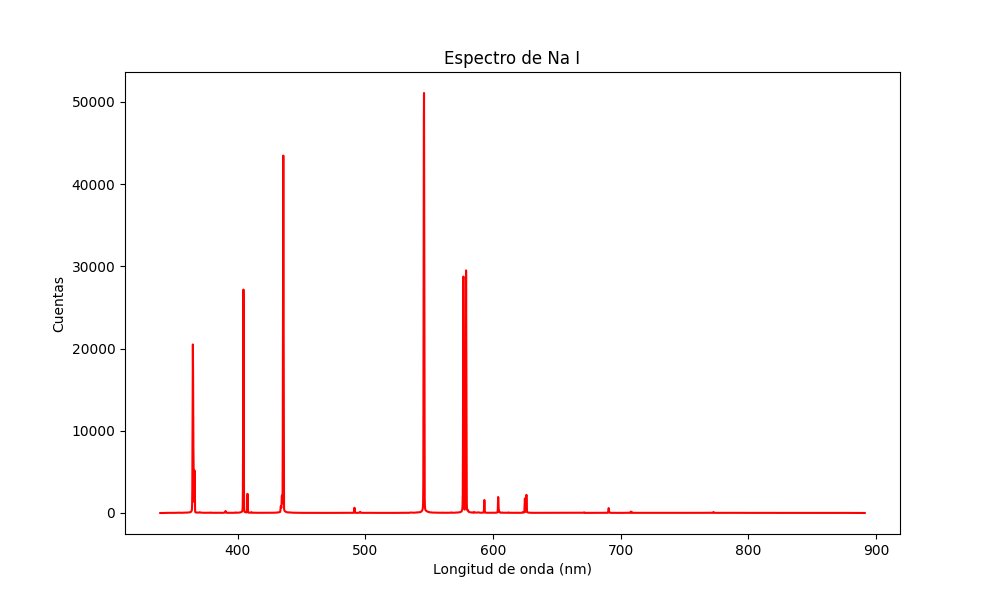

In [10]:
plt.figure(figsize=(10, 6))
plt.plot(Datos[:, 0], Datos[:, 4], label='Hg I', color='red')
plt.xlabel('Longitud de onda (nm)')
plt.ylabel('Cuentas')
plt.title('Espectro de Na I')
plt.show()